# PCA Demo

Click the "run" buttons in each code cell in order. The point of this demo is not for you to immediately learn the Python syntax, but to see that:

- you can easily implement the PCA algorithm from the slides (Section 2)
- that doing so makes it easier to visualize a dataset (Section 3)
- that there is a Python package that implements PCA for comparison (Section 6)

This notebook also shows how centering, eigenvalues, explained variance, and reconstruction fit together.


## 0. Load necessary packages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# This is just for comparison later
from sklearn.decomposition import PCA


## 1. Load the iris dataset

In [ ]:
# Load the iris data
iris = load_iris()
X = iris.data

# Get some metadata
labels = iris.target
feature_names = iris.feature_names
species = iris.target_names

print(f"Data shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Species: {species}")

n = X.shape[0]
p = X.shape[1]

print(f"The iris dataset has {n} examples and {p} features. The first five rows are:\n{X[:5]}.")


Data shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Species: ['setosa' 'versicolor' 'virginica']
The iris dataset has 150 examples and 4 features. The first five rows are:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]].


## 2. Implement the PCA algorithm

We follow the algorithm from the slides:

1. Center each feature by subtracting its mean.
2. Form the sample covariance matrix.
3. Find its eigenvalues and eigenvectors.
4. Sort the eigenvalues/eigenvectors by decreasing eigenvalue.
5. Retain the first $k$ principal component directions.
6. Project the centered observations onto those directions.

**A note about scaling:** Here we use the covariance matrix because all four Iris features are measured in centimeters. If features were measured on substantially different scales, we might standardize each feature before PCA; this is closely related to performing PCA on the correlation matrix.


In [ ]:
# 1. Center the data
# Each column is a feature, so subtract that feature's mean from every observation.
X_centered = X - X.mean(axis=0)

# Note that the formula from class also works:
# X_centered = X - (1/n) * np.ones((n,1)) @ np.ones((1,n)) @ X


In [ ]:
# 2. Form the sample covariance matrix
cov_matrix = X_centered.T @ X_centered / (n - 1)

print("Covariance matrix:")
print(np.round(cov_matrix, 3))


Covariance matrix:
[[ 0.686 -0.042  1.274  0.516]
 [-0.042  0.19  -0.33  -0.122]
 [ 1.274 -0.33   3.116  1.296]
 [ 0.516 -0.122  1.296  0.581]]


In [ ]:
# 3a. Get the eigenvectors and eigenvalues
lambdas, Vp = np.linalg.eigh(cov_matrix)

# 3b. Sort eigenstuff by decreasing eigenvalue
idx = np.argsort(lambdas)[::-1]
lambdas = lambdas[idx]
Vp = Vp[:, idx]

print("Eigenvalues (largest first):")
print(np.round(lambdas, 4))


Eigenvalues (largest first):
[4.2282 0.2427 0.0782 0.0238]


In [ ]:
# 4. Truncate to a dimension 1 <= k < p for dimensionality reduction
# (PCA itself can retain all p components; here we choose k < p to reduce dimension.)
k = 2
Vk = Vp[:, :k]

print(f"Retaining k = {k} principal components.")
print("Principal component directions (columns of Vk):")
print(np.round(Vk, 4))


Retaining k = 2 principal components.
Principal component directions (columns of Vk):
[[-0.3614  0.6566]
 [ 0.0845  0.7302]
 [-0.8567 -0.1734]
 [-0.3583 -0.0755]]


In [ ]:
# 5. Project to obtain the "scores" Z
# Each row of Z gives the coordinates of an observation in the
# principal-component coordinate system.
Z = X_centered @ Vk

print(f"The first five rows of the score matrix are:\n{Z[:5]}.")


The first five rows of the score matrix are:
[[ 2.68412563  0.31939725]
 [ 2.71414169 -0.17700123]
 [ 2.88899057 -0.14494943]
 [ 2.74534286 -0.31829898]
 [ 2.72871654  0.32675451]].


## 3. Scatter the first two principal components of the data

The first plot shows the first two **original feature axes** (after centering). The second plot shows the same observations after projection onto the first two principal component directions.

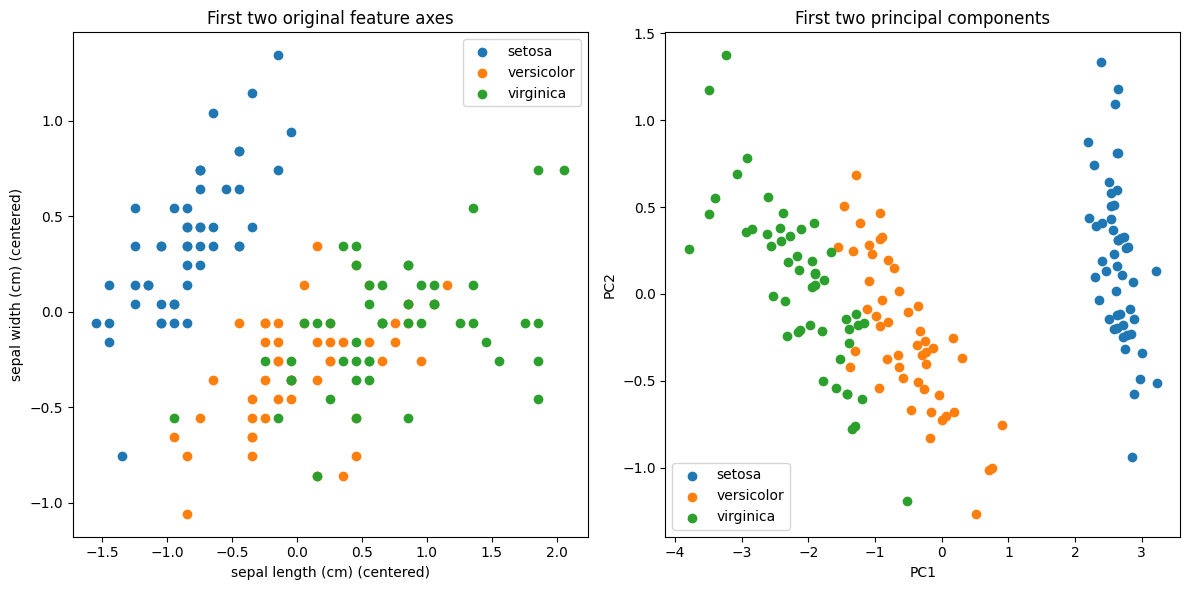

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# First two original feature axes
for label in np.unique(labels):
    mask = labels == label
    axes[0].scatter(
        X_centered[mask, 0],
        X_centered[mask, 1],
        label=species[label]
    )

axes[0].set_xlabel(feature_names[0] + " (centered)")
axes[0].set_ylabel(feature_names[1] + " (centered)")
axes[0].set_title("First two original feature axes")
axes[0].legend()

# First two principal components
for label in np.unique(labels):
    mask = labels == label
    axes[1].scatter(
        Z[mask, 0],
        Z[mask, 1],
        label=species[label]
    )

axes[1].set_xlabel("PC$_1$")
axes[1].set_ylabel("PC$_2$")
axes[1].set_title("First two principal components")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. How much variance do the principal components explain?

The eigenvalues of the covariance matrix give the variance along the corresponding principal component directions. Therefore,

$$
  \text{proportion of variance explained by PC$_j$}
= \frac{\lambda_j}{\lambda_1 + \lambda_2 + \cdots + \lambda_p}.
$$

The cumulative proportion tells us how much of the total variance is retained when we keep the first $k$ components.


In [ ]:
var_explained = lambdas / lambdas.sum()
cum_var_explained = np.cumsum(var_explained)

print("Variance explained by each component:")
for j in range(p):
    print(
        f"PC{j + 1}: {var_explained[j]:.4f} "
        f"({100 * var_explained[j]:.2f}%)"
    )

print(f"\nVariance explained by the first {k} components: "
      f"{100 * cum_var_explained[k - 1]:.2f}%")


Variance explained by each component:
PC1: 0.9246 (92.46%)
PC2: 0.0531 (5.31%)
PC3: 0.0171 (1.71%)
PC4: 0.0052 (0.52%)

Variance explained by the first 2 components: 97.77%


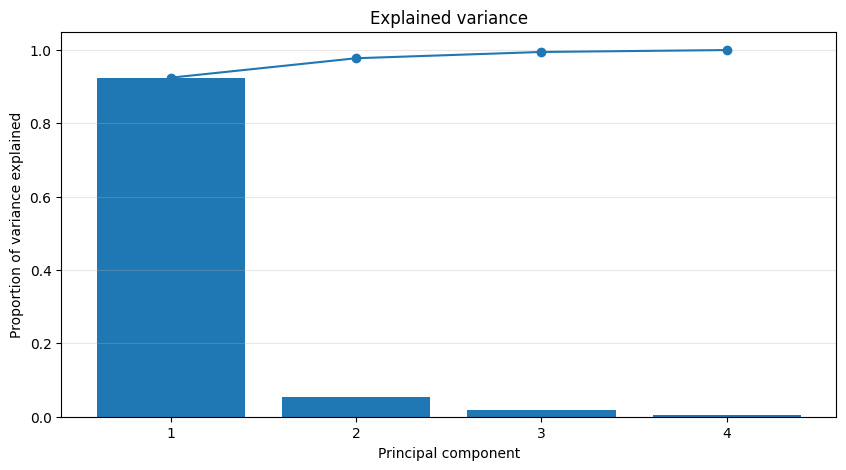

In [ ]:
components = np.arange(1, p + 1)

plt.figure(figsize=(10, 5))
plt.bar(components, var_explained)
plt.plot(components, cum_var_explained, marker="o")
plt.xticks(components)
plt.xlabel("Principal component")
plt.ylabel("Proportion of variance explained")
plt.title("Explained variance")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()


## 5. Reconstruct the data from the first $k$ components

PCA can also be viewed as a low-dimensional approximation of the original data.

Because the columns of $V_k$ are orthonormal, we can map the scores back into the original feature space with

$$
\widehat{X}_{centered} = Z V_k^\top.
$$

The reconstruction is approximate when $k < p$. This gives another useful interpretation of dimensionality reduction: we are replacing each observation with its closest representation in the retained principal component subspace.


In [ ]:
# Reconstruct the centered data using only the first k components
X_centered_hat = Z @ Vk.T

# Add the original feature means back to obtain an approximation on the
# original measurement scale.
X_hat = X_centered_hat + X.mean(axis=0)

# Mean squared reconstruction error
reconstruction_error = np.mean((X - X_hat) ** 2)

print(f"Mean squared reconstruction error using k = {k}: "
      f"{reconstruction_error:.4f}")
print("\nFirst five reconstructed observations:")
print(np.round(X_hat[:5], 3))


Mean squared reconstruction error using k = 2: 0.0253

First five reconstructed observations:
[[5.083 3.517 1.403 0.214]
 [4.746 3.157 1.464 0.24 ]
 [4.704 3.196 1.308 0.175]
 [4.642 3.057 1.461 0.24 ]
 [5.072 3.527 1.364 0.197]]


## 6. Compare with scikit-learn

Finally, we can compare our implementation with `sklearn`.

One subtle point: **the sign of an eigenvector is arbitrary**. If $v$ is an eigenvector, then $-v$ is also an eigenvector. Consequently, corresponding principal components from two correct implementations can differ only by a sign.

So, when comparing components, we should not interpret a sign flip as a disagreement.


In [ ]:
# sklearn's PCA centers the data by default.
pca = PCA(n_components=k)
Z_sklearn = pca.fit_transform(X)

print("Our principal-component directions:")
print(np.round(Vk, 4))

print("\nscikit-learn principal-component directions:")
print(np.round(pca.components_.T, 4))

# Align signs before comparing. This accounts for the eigenvector sign ambiguity.
sklearn_components = pca.components_.T.copy()
for j in range(k):
    if np.dot(Vk[:, j], sklearn_components[:, j]) < 0:
        sklearn_components[:, j] *= -1

print("\nAfter aligning signs, maximum absolute difference:")
print(np.max(np.abs(Vk - sklearn_components)))


Our principal-component directions:
[[-0.3614  0.6566]
 [ 0.0845  0.7302]
 [-0.8567 -0.1734]
 [-0.3583 -0.0755]]

scikit-learn principal-component directions:
[[ 0.3614  0.6566]
 [-0.0845  0.7302]
 [ 0.8567 -0.1734]
 [ 0.3583 -0.0755]]

After aligning signs, maximum absolute difference:
2.0317081350640365e-14


In [ ]:
print("Our explained variance ratio:")
print(np.round(var_explained[:k], 6))

print("\nscikit-learn explained variance ratio:")
print(np.round(pca.explained_variance_ratio_, 6))


Our explained variance ratio:
[0.924619 0.053066]

scikit-learn explained variance ratio:
[0.924619 0.053066]


### Summary

The main ideas to take away are:

- PCA begins by centering the features.
- The covariance matrix summarizes how the features vary together.
- Its eigenvectors give the principal component directions.
- Its eigenvalues give the variance captured along those directions.
- Projecting onto the first $k$ directions gives a lower-dimensional representation.
- The retained components can be used to reconstruct an approximation of the original data.
- `sklearn.decomposition.PCA` performs the same basic procedure for this setting, with differences in implementation details that are useful to understand.
